# Common Libraries

In [1]:
import os, sys, shutil, functools
import numpy as np
from typing import List, Dict, Tuple
from copy import deepcopy
import matplotlib.pylab as plt

if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"

# Mujoco
import mujoco

# Custom Libraries

In [49]:
def render_models(models, renderes, site_group_idx = []):
    # Scene option
    scene_option = mujoco.MjvOption()

    for site_group_i, _ in enumerate(scene_option.sitegroup):
        if site_group_i in site_group_idx:
            scene_option.sitegroup[site_group_i] = 1
        else:
            scene_option.sitegroup[site_group_i] = 0

    # Render
    for model, renderer in zip(models, renderers):
        data = mujoco.MjData(model)
        mujoco.mj_forward(model, data)
        renderer.update_scene(data, camera=camera, scene_option=scene_option)

    # Make image
    fig, axes = plt.subplots(1, len(renderers))
    fig.set_figwidth(15)
    axes = axes.flatten()

    for i, renderer in enumerate(renderers):
        axes[i].imshow(renderer.render())
        axes[i].axis("off")


# Params

In [35]:
model_path = "/home/seojin/biomechanics_tools/MonocularBiomechanics/monocular_demos/biomechanics_mjx/data/humanoid/humanoid_torque.xml"
# model_path = "/mnt/sdb2/DeepProprioception/MyoSuite/muscle_mimic/muscle_mimic.xml"
scale = 2
save_path = "/mnt/ext1/seojin/temp/scale/scaled_param.npz"

is_plot = True

# Initialize model

In [36]:
# Mujoco model
origin_model = mujoco.MjModel.from_xml_path(model_path)
scaled_model = deepcopy(origin_model)

## Body
body_names = np.array([origin_model.body(i).name for i in range(len(origin_model.body_pos))])
target_body_names = body_names[np.isin(body_names, ["world"]) == False]
target_body_ids = [mujoco.mj_name2id(origin_model, mujoco.mjtObj.mjOBJ_BODY, body_name) for body_name in target_body_names]

## Tendon
muscle_actuated = origin_model.actuator_trntype == mujoco.mjtTrn.mjTRN_TENDON
tendon_ids = origin_model.actuator_trnid[muscle_actuated, 0]
tendon_names = [mujoco.mj_id2name(origin_model, mujoco.mjtObj.mjOBJ_TENDON, int(t_id)) for t_id in tendon_ids]

# Constants

In [37]:
n_bodies = origin_model.nbody
n_sites = origin_model.nsite
n_geoms = origin_model.ngeom
n_vertices = origin_model.nmeshvert

scales = np.ones((n_bodies, 1)) 
scales[target_body_ids] = scales[target_body_ids, :] * scale

# Visualization

In [38]:
# Camera
camera = mujoco.MjvCamera()
camera.type = mujoco.mjtCamera.mjCAMERA_FREE
camera.lookat[:] = [0, 0, 0]
camera.distance = 6.0
camera.azimuth = -180
camera.elevation = -20

models = [origin_model, scaled_model]

renderers = []
for model in models:
    # Remove ground
    for geom_id in range(model.ngeom):
        if model.geom_type[geom_id] == mujoco.mjtGeom.mjGEOM_PLANE:
            model.geom_rgba[geom_id, 3] = 0.0
    renderers.append(mujoco.Renderer(model, height=400, width=600))

# Body

In [39]:
body_mixer = np.zeros((n_bodies, n_bodies))
idx0 = np.arange(n_bodies)
idx1 = origin_model.body_parentid

body_mixer[idx0, idx1] = 1
body_scale = body_mixer @ scales

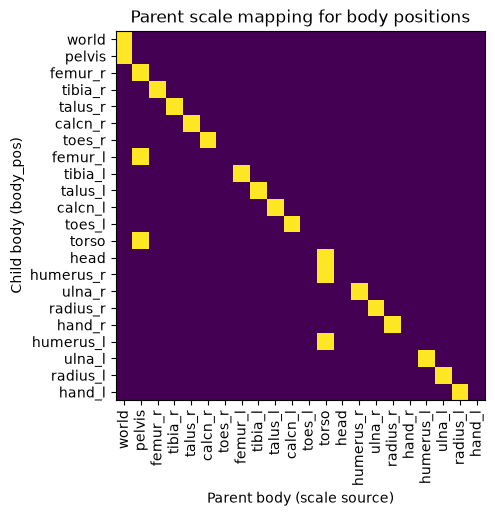

In [40]:
if is_plot:
    fig, axis = plt.subplots(1)
    axis.imshow(body_mixer)
    axis.set_xticks(np.arange(len(body_names)), body_names, rotation = 90)
    axis.set_yticks(np.arange(len(body_names)), body_names)
    
    axis.set_xlabel("Parent body (scale source)")
    axis.set_ylabel("Child body (body_pos)")
    axis.set_title("Parent scale mapping for body positions")

In [41]:
scaled_model.body_pos = origin_model.body_pos * body_scale

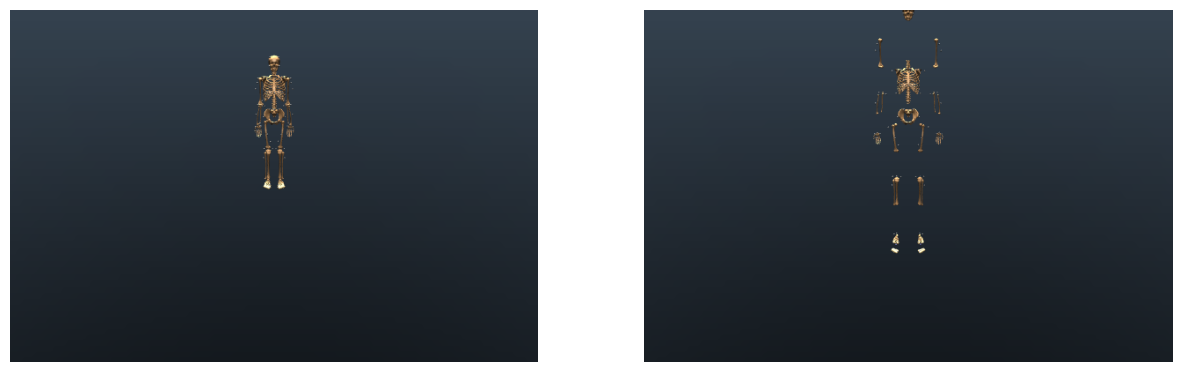

In [42]:
render_models(models, renderers, site_group_idx = np.arange(6))

# Site

In [43]:
site_mixer = np.zeros((n_sites, n_bodies))
idx0 = np.arange(n_sites)
idx1 = origin_model.site_bodyid
site_mixer[idx0, idx1] = 1.0
site_scale = site_mixer @ scales
scaled_model.site_pos = origin_model.site_pos * site_scale

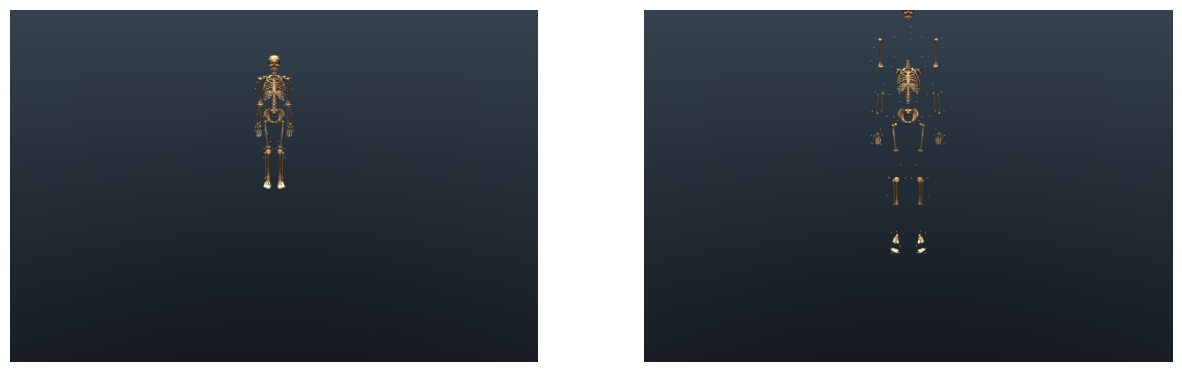

In [44]:
render_models(models, renderers, site_group_idx = np.arange(6))

# Geometry

In [45]:
geom_mixer = np.zeros((n_geoms, n_bodies))
idx0 = np.arange(n_geoms)
idx1 = origin_model.geom_bodyid
geom_mixer[idx0, idx1] = 1.0
geom_scale = geom_mixer @ scales
scaled_model.geom_pos = origin_model.geom_pos * geom_scale
scaled_model.geom_size = origin_model.geom_size * geom_scale

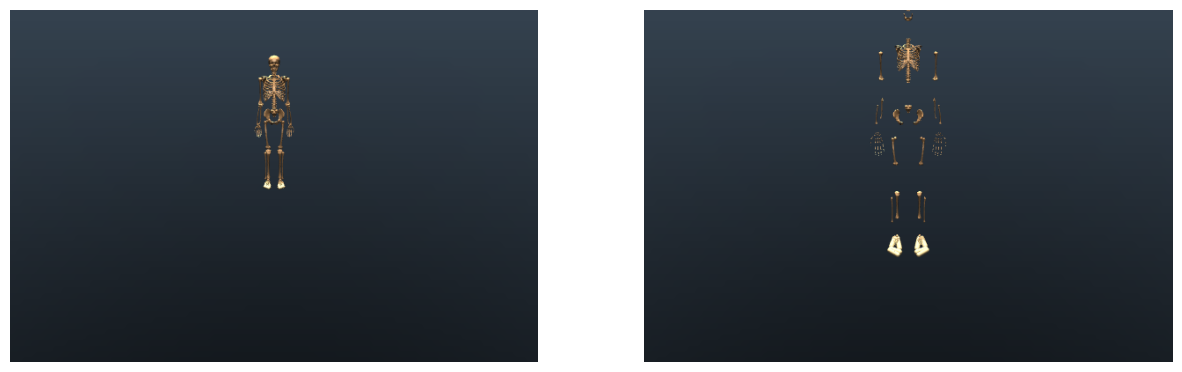

In [46]:
render_models(models, renderers)

# Vertex

In [52]:
vertex_mixer = np.zeros((n_vertices, n_bodies))
for i in np.arange(n_bodies):
    for g in np.arange(origin_model.body_geomadr[i], origin_model.body_geomadr[i] + origin_model.body_geomnum[i]):
        mesh_id = origin_model.geom_dataid[g]
        if mesh_id != -1:
            vertex_mixer[origin_model.mesh_vertadr[mesh_id] : origin_model.mesh_vertadr[mesh_id] + origin_model.mesh_vertnum[mesh_id], i] = 1
vertex_scale = vertex_mixer @ scales
scaled_model.mesh_vert = origin_model.mesh_vert * vertex_scale

In [53]:
for model, render in zip(models, renderers):
    for mesh_id in range(model.nmesh):
        mujoco.mjr_uploadMesh(model, render._mjr_context, mesh_id)

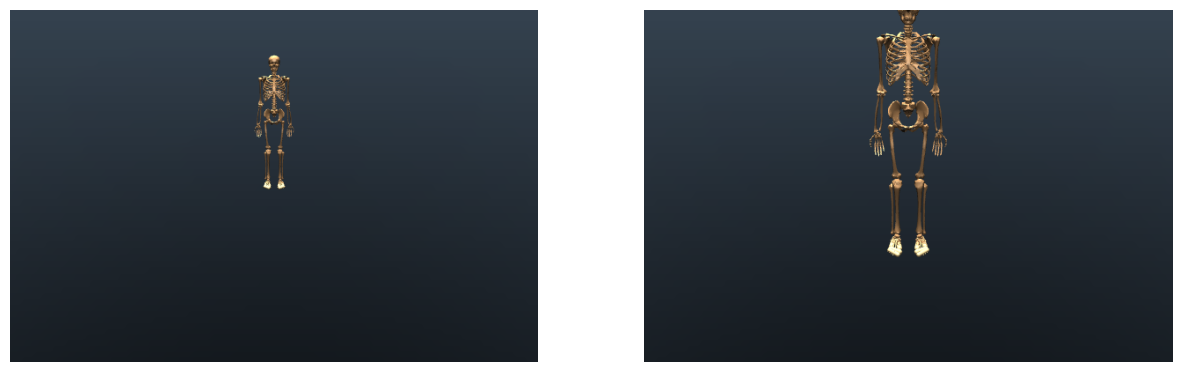

In [54]:
render_models(models, renderers)

# Tendon

In [55]:
origin_tendon_length = deepcopy(origin_model.tendon_length0)

In [56]:
muscle_actuated = scaled_model.actuator_trntype == mujoco.mjtTrn.mjTRN_TENDON
data = mujoco.MjData(scaled_model)
data.qpos = scaled_model.qpos0
mujoco.mj_forward(scaled_model, data)
scaled_model.tendon_length0[tendon_ids] = data.ten_length[tendon_ids]

In [57]:
scaled_tendon_length = deepcopy(scaled_model.tendon_length0)

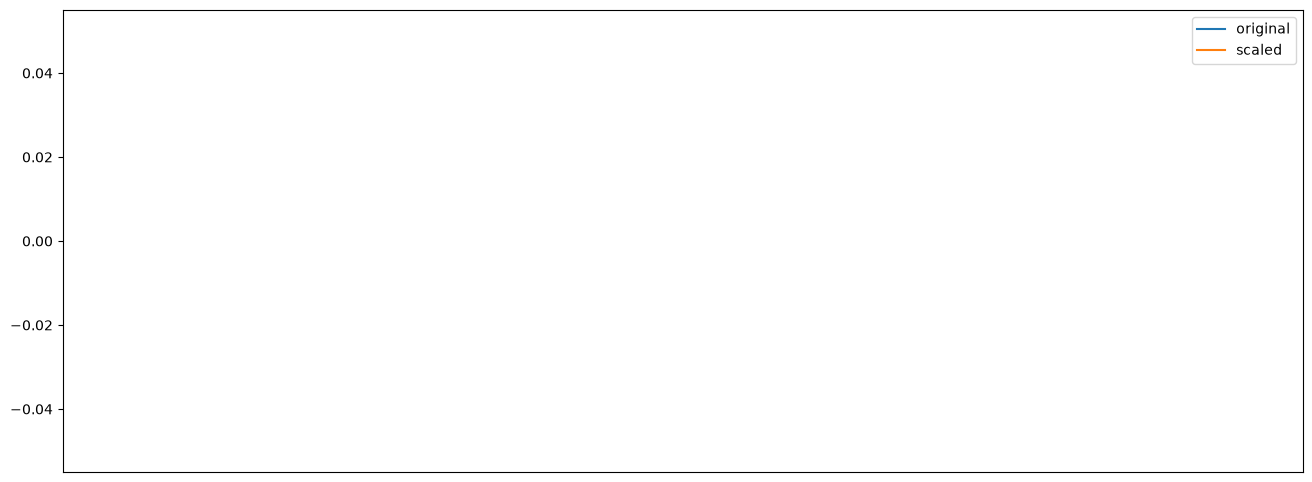

In [58]:
if is_plot:
    fig, axis = plt.subplots(1)
    fig.set_figwidth(16)
    fig.set_figheight(6)
    plt.plot(origin_tendon_length, label = "original")
    plt.plot(scaled_tendon_length, label = "scaled")
    plt.xticks(np.arange(len(tendon_names)), tendon_names, rotation = 90)
    plt.legend()

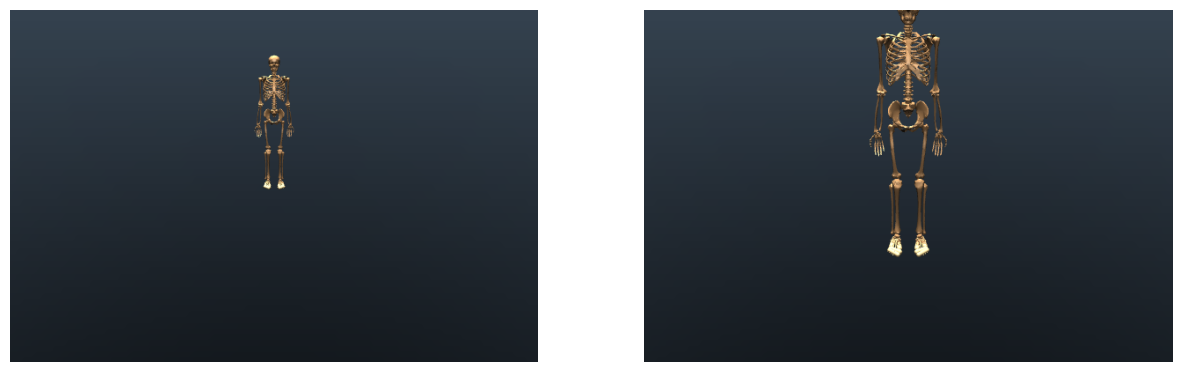

In [60]:
render_models(models, renderers)

# Save result

In [61]:
params_to_save = {
    "body_pos": scaled_model.body_pos,
    "site_pos": scaled_model.site_pos,
    "geom_pos": scaled_model.geom_pos,
    "geom_size": scaled_model.geom_size,
    "tendon_length0" : scaled_model.tendon_length0,
}

np.savez(save_path, **params_to_save)
print(f"save: {save_path}")

save: /mnt/ext1/seojin/temp/scale/scaled_param.npz
